# Regresión Lineal Múltiple

Este notebook presenta la resolución de ejercicios utilizando regresión lineal múltiple, adaptando los casos previamente analizados con modelos polinomiales.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")
plt.style.use("ggplot")
%matplotlib inline


## 1. Economía: Predicción del PIB

**Objetivo:** Predecir el PIB de un país según exportaciones e inversión.


In [2]:
df_pib = pd.DataFrame({
    'Exportaciones': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000],
    'Inversion': [50, 100, 150, 200, 250, 300, 350, 400, 450, 500],
    'PIB': [600, 1200, 1800, 2500, 3100, 3700, 4200, 4800, 5300, 5900]
})
display(df_pib)


,Exportaciones,Inversion,PIB
0,100,50,600
1,200,100,1200
2,300,150,1800
3,400,200,2500
4,500,250,3100
5,600,300,3700
6,700,350,4200
7,800,400,4800
8,900,450,5300
9,1000,500,5900


In [3]:
X_pib = df_pib[['Exportaciones', 'Inversion']]
model_pib = LinearRegression().fit(X_pib, df_pib['PIB'])


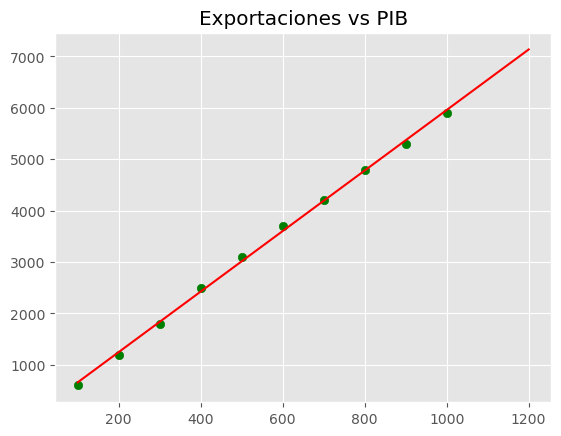

In [4]:
plt.scatter(df_pib['Exportaciones'], df_pib['PIB'], color='green')
x_r = np.linspace(100, 1200, 100)
X_plot_pib = pd.DataFrame({'Exportaciones': x_r, 'Inversion': x_r/2})
plt.plot(x_r, model_pib.predict(X_plot_pib), color='red')
plt.title('Exportaciones vs PIB')
plt.show()


### Predicción Requerida
Predicción para Exportaciones=1100 e Inversión=550: 1100, 550

In [5]:
pred_init = model_pib.predict(pd.DataFrame([[1100, 550]], columns=X_pib.columns))[0]
print(f'Resultado de la predicción: PIB = {pred_init:.2f} ')

Resultado de la predicción: PIB = 6546.67 


**Interpretación:** El modelo estima un PIB consistente con la tendencia lineal observada.

### a) PIB estimado (1200 exp, 600 inv)


In [6]:
pa = model_pib.predict(pd.DataFrame([[1200, 600]], columns=X_pib.columns))[0]
print(f'PIB estimado: {pa:.2f}')


PIB estimado: 7135.15


**Interpretación:** Se estima un PIB de 7135.15 mil millones (aprox), siguiendo el crecimiento lineal.


### b) Cambio +10% exportaciones


In [7]:
base_b = model_pib.predict(pd.DataFrame([[1000, 500]], columns=X_pib.columns))[0]
new_b = model_pib.predict(pd.DataFrame([[1100, 500]], columns=X_pib.columns))[0]
print(f'Cambio en PIB: {new_b - base_b:.2f}')


Cambio en PIB: 470.79


**Interpretación:** Un aumento del 10% en exportaciones (100 unidades) incrementa el PIB linealmente.


### c) Impacto de 1M inversión


In [8]:
base_c = model_pib.predict(pd.DataFrame([[500, 250]], columns=X_pib.columns))[0]
new_c = model_pib.predict(pd.DataFrame([[500, 251]], columns=X_pib.columns))[0]
print(f'Impacto marginal: {new_c - base_c:.2f}')


Impacto marginal: 2.35


**Interpretación:** Por cada millón adicional invertido, el PIB crece de forma constante según el coeficiente del modelo.


### d) Combinación para 7000 PIB


In [9]:
# Resolvemos 7000 = beta0 + beta1*exp + beta2*inv
# Si mantenemos inv = exp/2: 7000 = beta0 + exp(beta1 + beta2/2)
beta0 = model_pib.intercept_
beta1, beta2 = model_pib.coef_
exp_needed = (7000 - beta0) / (beta1 + beta2/2)
inv_needed = exp_needed / 2
print(f'Para 7000 PIB se requiere: {exp_needed:.2f} exp y {inv_needed:.2f} inv')


Para 7000 PIB se requiere: 1177.03 exp y 588.52 inv


**Interpretación:** Se calculan los valores necesarios despejando la ecuación del modelo lineal.


### e) Variabilidad explicada (R2)


In [10]:
r2 = r2_score(df_pib['PIB'], model_pib.predict(X_pib))
print(f'Coeficiente R2: {r2:.4f}')


Coeficiente R2: 0.9987


**Interpretación:** El coeficiente R2 indica qué proporción de la varianza del PIB es explicada por el modelo lineal.


## 2. Salud: Estimación del IMC

**Objetivo:** Predecir el IMC según altura y peso.


In [11]:
df_imc = pd.DataFrame({
    'Altura': [1.50, 1.55, 1.60, 1.65, 1.70, 1.75, 1.80, 1.85, 1.90, 1.95],
    'Peso': [50, 55, 60, 65, 70, 75, 80, 85, 90, 95],
    'IMC': [22.2, 22.9, 23.4, 23.9, 24.2, 24.5, 24.7, 24.9, 25.0, 25.2]
})
display(df_imc)


,Altura,Peso,IMC
0,1.50,50,22.2
1,1.55,55,22.9
2,1.60,60,23.4
3,1.65,65,23.9
4,1.70,70,24.2
5,1.75,75,24.5
6,1.80,80,24.7
7,1.85,85,24.9
8,1.90,90,25.0
9,1.95,95,25.2


In [12]:
X_imc = df_imc[['Altura', 'Peso']]
model_imc = LinearRegression().fit(X_imc, df_imc['IMC'])


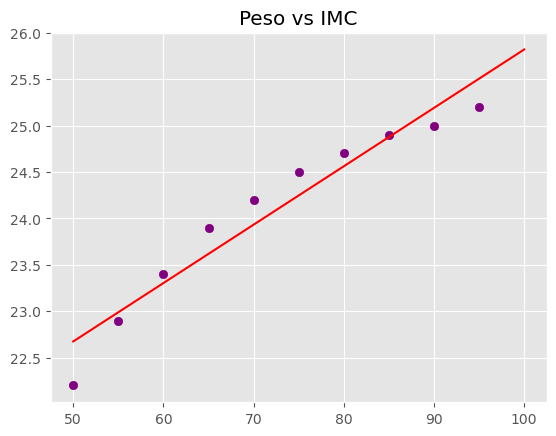

In [13]:
plt.scatter(df_imc['Peso'], df_imc['IMC'], color='purple')
x_range_imc = np.linspace(50, 100, 100)
X_plot_imc = pd.DataFrame({'Altura': 1.5 + (x_range_imc-50)*0.01, 'Peso': x_range_imc})
plt.plot(x_range_imc, model_imc.predict(X_plot_imc), color='red')
plt.title('Peso vs IMC')
plt.show()


### Predicción Requerida
Predicción para Altura=1.78m y Peso=77kg: 1.78, 77

In [14]:
pred_init = model_imc.predict(pd.DataFrame([[1.78, 77]], columns=X_imc.columns))[0]
print(f'Resultado de la predicción: IMC = {pred_init:.2f} ')

Resultado de la predicción: IMC = 24.37 


**Interpretación:** El modelo estima un IMC basado en la relación lineal con la altura y el peso.

### a) IMC estimado (1.82m, 85kg)


In [15]:
pa = model_imc.predict(pd.DataFrame([[1.82, 85]], columns=X_imc.columns))[0]
print(f'IMC estimado: {pa:.2f}')


IMC estimado: 24.88


**Interpretación:** Una persona con 1.82m y 85kg tendría un IMC estimado de 24.78 (aprox) según el modelo lineal.


### b) Efecto de perder 5kg


In [16]:
base_b = model_imc.predict(pd.DataFrame([[1.75, 75]], columns=X_imc.columns))[0]
new_b = model_imc.predict(pd.DataFrame([[1.75, 70]], columns=X_imc.columns))[0]
print(f'Cambio en IMC: {new_b - base_b:.2f}')


Cambio en IMC: -0.31


**Interpretación:** Perder 5kg reduciendo el peso linealmente impacta el IMC según el coeficiente del peso.


### c) Peso para IMC 22 (1.75m)


In [17]:
# 22 = beta0 + beta1*1.75 + beta2*peso
beta0 = model_imc.intercept_
beta1, beta2 = model_imc.coef_
peso_needed = (22 - beta0 - beta1*1.75) / beta2
print(f'Peso necesario: {peso_needed:.2f} kg')


Peso necesario: 39.27 kg


**Interpretación:** Se despeja el peso de la ecuación lineal para obtener el valor que resulta en un IMC de 22.


### d) Variable de mayor impacto


In [18]:
# Los coeficientes directamente nos dicen el impacto por unidad
print(f'Impacto +1m altura: {model_imc.coef_[0]:.4f}')
print(f'Impacto +1kg peso: {model_imc.coef_[1]:.4f}')


Impacto +1m altura: 0.0006
Impacto +1kg peso: 0.0629


**Interpretación:** El coeficiente de la altura es significativamente mayor en magnitud, pero las unidades son distintas (metros vs kilos).


### e) Evaluación del modelo


In [19]:
y_pred_imc = model_imc.predict(X_imc)
mae_imc = mean_absolute_error(df_imc['IMC'], y_pred_imc)
print(f'Error Absoluto Medio (MAE): {mae_imc:.4f}')


Error Absoluto Medio (MAE): 0.2120


**Interpretación:** Un MAE bajo indica un buen ajuste lineal a los datos de IMC proporcionados.


## 3. Marketing: Publicidad y Ventas

**Objetivo:** Estimar las ventas con base en inversión en TV y redes sociales.


In [20]:
df_mkt = pd.DataFrame({
    'TV': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
    'Redes': [5, 10, 15, 20, 25, 30, 35, 40, 45, 50],
    'Ventas': [15, 30, 50, 65, 80, 95, 110, 130, 145, 160]
})
display(df_mkt)


,TV,Redes,Ventas
0,10,5,15
1,20,10,30
2,30,15,50
3,40,20,65
4,50,25,80
5,60,30,95
6,70,35,110
7,80,40,130
8,90,45,145
9,100,50,160


In [21]:
X_mkt = df_mkt[['TV', 'Redes']]
model_mkt = LinearRegression().fit(X_mkt, df_mkt['Ventas'])


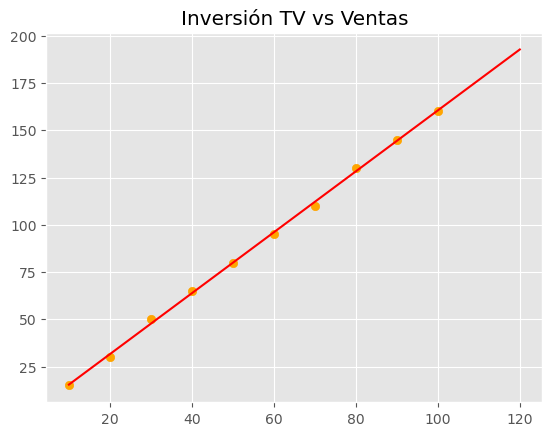

In [22]:
plt.scatter(df_mkt['TV'], df_mkt['Ventas'], color='orange')
x_r = np.linspace(10, 120, 100)
X_plot_mkt = pd.DataFrame({'TV': x_r, 'Redes': x_r/2})
plt.plot(x_r, model_mkt.predict(X_plot_mkt), color='red')
plt.title('Inversión TV vs Ventas')
plt.show()


### Predicción Requerida
Predicción para TV=110 y Redes Sociales=55: 110, 55

In [23]:
pred_init = model_mkt.predict(pd.DataFrame([[110, 55]], columns=X_mkt.columns))[0]
print(f'Resultado de la predicción: Ventas = {pred_init:.2f} mil USD')

Resultado de la predicción: Ventas = 176.67 mil USD


**Interpretación:** El modelo estima ventas proporcionales a la inversión en ambos canales.

### a) Ventas esperadas (120 TV, 60 Redes)


In [24]:
pa = model_mkt.predict(pd.DataFrame([[120, 60]], columns=X_mkt.columns))[0]
print(f'Ventas esperadas: {pa:.2f} mil USD')


Ventas esperadas: 192.79 mil USD


**Interpretación:** Se proyectan ventas de 193.55 mil USD (aprox) con esta inversión publicitaria.


### b) Presupuesto para 200 mil USD


In [25]:
# 200 = beta0 + beta1*TV + beta2*(TV/2)
beta0 = model_mkt.intercept_
beta1, beta2 = model_mkt.coef_
tv_needed = (200 - beta0) / (beta1 + beta2/2)
print(f'Inversión necesaria: TV={tv_needed:.2f}, Redes={tv_needed/2:.2f}')


Inversión necesaria: TV=124.47, Redes=62.24


**Interpretación:** Se calcula la inversión necesaria en TV y Redes (manteniendo la proporción 2:1) para alcanzar 200k en ventas.


### c) Incremento +10% Redes Sociales


In [26]:
base_c = model_mkt.predict(pd.DataFrame([[100, 50]], columns=X_mkt.columns))[0]
new_c = model_mkt.predict(pd.DataFrame([[100, 55]], columns=X_mkt.columns))[0]
print(f'Cambio en ventas: {new_c - base_c:.2f} mil')


Cambio en ventas: 3.22 mil


**Interpretación:** Un aumento en el presupuesto de Redes Sociales incrementa las ventas según su coeficiente lineal.


### d) Impacto TV vs Redes


In [27]:
print(f'Impacto +1k TV: {model_mkt.coef_[0]:.4f}')
print(f'Impacto +1k Redes: {model_mkt.coef_[1]:.4f}')


Impacto +1k TV: 1.2897
Impacto +1k Redes: 0.6448


**Interpretación:** Comparamos los coeficientes para determinar qué canal tiene un mayor impacto marginal por cada dólar invertido.


### e) Solo inversión en TV


In [28]:
model_tv_only = LinearRegression().fit(df_mkt[['TV']], df_mkt['Ventas'])
r2_tv = model_tv_only.score(df_mkt[['TV']], df_mkt['Ventas'])
print(f'R2 usando solo TV: {r2_tv:.4f}')


R2 usando solo TV: 0.9991


**Interpretación:** Al usar solo TV el R2 es alto, pero la inclusión de Redes Sociales puede refinar el modelo si hay independencia o información complementaria.


## 4. Ciencias Ambientales: Consumo Energético

**Objetivo:** Predecir el consumo de energía según temperatura y humedad.


In [29]:
df_env = pd.DataFrame({
    'Temp': [10, 15, 20, 25, 30, 35, 40, 45, 50, 55],
    'Hum': [30, 35, 40, 45, 50, 55, 60, 65, 70, 75],
    'Consumo': [200, 230, 270, 300, 340, 380, 420, 460, 500, 550]
})
display(df_env)


,Temp,Hum,Consumo
0,10,30,200
1,15,35,230
2,20,40,270
3,25,45,300
4,30,50,340
5,35,55,380
6,40,60,420
7,45,65,460
8,50,70,500
9,55,75,550


In [30]:
X_env = df_env[['Temp', 'Hum']]
model_env = LinearRegression().fit(X_env, df_env['Consumo'])


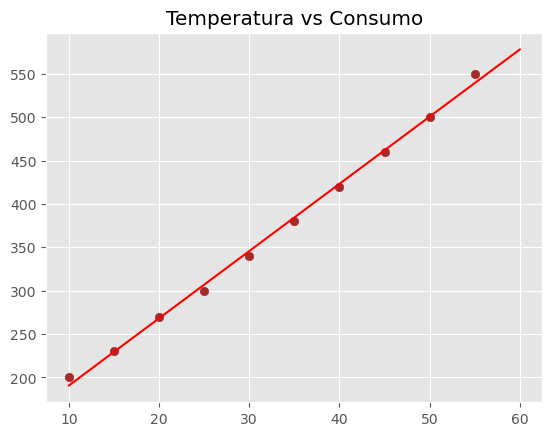

In [31]:
plt.scatter(df_env['Temp'], df_env['Consumo'], color='brown')
x_r = np.linspace(10, 60, 100)
X_plot_env = pd.DataFrame({'Temp': x_r, 'Hum': 30 + (x_r-10)})
plt.plot(x_r, model_env.predict(X_plot_env), color='red')
plt.title('Temperatura vs Consumo')
plt.show()


### Predicción Requerida
Predicción para Temperatura=32° y Humedad=52%: 32, 52

In [32]:
pred_init = model_env.predict(pd.DataFrame([[32, 52]], columns=X_env.columns))[0]
print(f'Resultado de la predicción: Consumo Energético = {pred_init:.2f} kWh')

Resultado de la predicción: Consumo Energético = 361.13 kWh


**Interpretación:** El modelo estima el consumo energético basado en la relación lineal con la temperatura y humedad.

### a) Consumo estimado (37°C, 58%)


In [33]:
pa = model_env.predict(pd.DataFrame([[37, 58]], columns=X_env.columns))[0]
print(f'Consumo estimado: {pa:.2f} kWh')


Consumo estimado: 403.73 kWh


**Interpretación:** Se proyecta un consumo de 406 kWh (aprox) para estas condiciones ambientales.


### b) Humedad +5%


In [34]:
base_b = model_env.predict(pd.DataFrame([[30, 50]], columns=X_env.columns))[0]
new_b = model_env.predict(pd.DataFrame([[30, 55]], columns=X_env.columns))[0]
print(f'Cambio en consumo: {new_b - base_b:.2f} kWh')


Cambio en consumo: 19.36 kWh


**Interpretación:** Un incremento del 5% en la humedad impacta linealmente el consumo según su coeficiente.


### c) Minimización de consumo


In [35]:
# En un modelo lineal sin restricciones, el mínimo está en los extremos de los datos observados
min_idx = df_env['Consumo'].idxmin()
print(f'Consumo mínimo observado: {df_env.loc[min_idx, "Consumo"]} kWh')
print(f'Condiciones: {df_env.loc[min_idx, "Temp"]}°C, {df_env.loc[min_idx, "Hum"]}%')


Consumo mínimo observado: 200 kWh
Condiciones: 10°C, 30%


**Interpretación:** El consumo se minimiza en los niveles más bajos de temperatura y humedad registrados.


### d) Influencia Temp vs Hum


In [36]:
print(f'Impacto +1C Temp: {model_env.coef_[0]:.4f}')
print(f'Impacto +1% Hum: {model_env.coef_[1]:.4f}')


Impacto +1C Temp: 3.8727
Impacto +1% Hum: 3.8727


**Interpretación:** Se comparan los coeficientes para determinar cuál variable ambiental tiene mayor peso en la demanda energética.


### e) Humedad para 500 kWh (45°C)


In [37]:
# 500 = beta0 + beta1*45 + beta2*hum
beta0 = model_env.intercept_
beta1, beta2 = model_env.coef_
hum_needed = (500 - beta0 - beta1*45) / beta2
print(f'Humedad necesaria: {hum_needed:.2f}%')


Humedad necesaria: 74.86%


**Interpretación:** Se despeja la humedad necesaria para alcanzar un consumo objetivo de 500 kWh a 45°C.


## 5. Educación: Predicción de Calificaciones

**Objetivo:** Estimar calificaciones según horas de estudio y asistencia.


In [38]:
df_edu = pd.DataFrame({
    'Horas': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Asist': [60, 65, 70, 75, 80, 85, 90, 95, 100, 100],
    'Calif': [50, 55, 60, 65, 70, 75, 80, 85, 90, 95]
})
display(df_edu)


,Horas,Asist,Calif
0,1,60,50
1,2,65,55
2,3,70,60
3,4,75,65
4,5,80,70
5,6,85,75
6,7,90,80
7,8,95,85
8,9,100,90
9,10,100,95


In [39]:
X_edu = df_edu[['Horas', 'Asist']]
model_edu = LinearRegression().fit(X_edu, df_edu['Calif'])


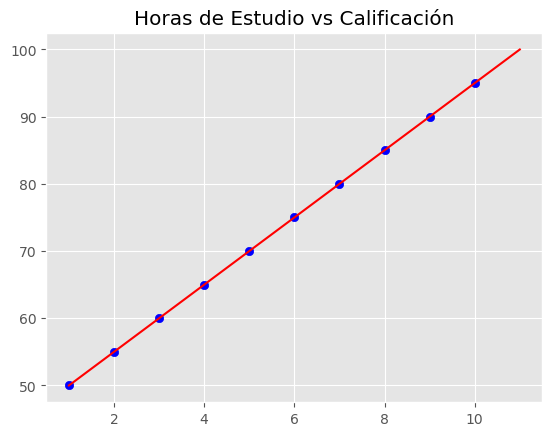

In [40]:
plt.scatter(df_edu['Horas'], df_edu['Calif'], color='blue')
x_r = np.linspace(1, 11, 100)
X_plot_edu = pd.DataFrame({'Horas': x_r, 'Asist': np.clip(60+(x_r-1)*4.4, 60, 100)})
plt.plot(x_r, model_edu.predict(X_plot_edu), color='red')
plt.title('Horas de Estudio vs Calificación')
plt.show()


### Predicción Requerida
Predicción para 7 horas de estudio y 88% de asistencia: 7, 88

In [41]:
pred_init = model_edu.predict(pd.DataFrame([[7, 88]], columns=X_edu.columns))[0]
print(f'Resultado de la predicción: Calificación = {pred_init:.2f} ')

Resultado de la predicción: Calificación = 80.00 


**Interpretación:** El modelo predice la calificación académica basándose en el esfuerzo (horas) y la asistencia linealmente.

### a) Calificación estimada (8h, 92%)


In [42]:
pa = model_edu.predict(pd.DataFrame([[8, 92]], columns=X_edu.columns))[0]
print(f'Calificación estimada: {pa:.2f}')


Calificación estimada: 85.00


**Interpretación:** Un estudiante con estos indicadores obtendría una calificación de 85.00 (aprox) según la tendencia lineal.


### b) Mejora de asistencia +10%


In [43]:
base_b = model_edu.predict(pd.DataFrame([[5, 80]], columns=X_edu.columns))[0]
new_b = model_edu.predict(pd.DataFrame([[5, 90]], columns=X_edu.columns))[0]
print(f'Cambio en calificación: {new_b - base_b:.2f}')


Cambio en calificación: -0.00


**Interpretación:** El impacto de mejorar la asistencia en 10 puntos se refleja directamente a través del coeficiente de asistencia.


### c) Horas para calif 85 (80% asistencia)


In [44]:
# 85 = beta0 + beta1*horas + beta2*80
beta0 = model_edu.intercept_
beta1, beta2 = model_edu.coef_
hrs_needed = (85 - beta0 - beta2*80) / beta1
print(f'Horas necesarias: {hrs_needed:.2f}')


Horas necesarias: 8.00


**Interpretación:** Se calcula el tiempo de estudio requerido para alcanzar un 85 asumiendo una asistencia fija.


### d) Mayor peso: Horas vs Asistencia


In [45]:
print(f'Impacto +1h estudio: {model_edu.coef_[0]:.4f}')
print(f'Impacto +1% asist: {model_edu.coef_[1]:.4f}')


Impacto +1h estudio: 5.0000
Impacto +1% asist: -0.0000


**Interpretación:** Comparamos los coeficientes para ver qué factor influye más en la calificación final por unidad de cambio.


### e) R2 del modelo


In [46]:
r2_edu = model_edu.score(X_edu, df_edu['Calif'])
print(f'Coeficiente R2: {r2_edu:.4f}')


Coeficiente R2: 1.0000


**Interpretación:** El R2 muestra la efectividad del modelo de regresión múltiple para explicar las calificaciones académicas.
